In [1]:
!pip install control numpy matplotlib

import numpy as np
import matplotlib.pyplot as plt
import control as ct

print("Libraries imported successfully.")

Defaulting to user installation because normal site-packages is not writeable
Libraries imported successfully.


In [2]:
# User Instructions: 
# Select the system representation by setting 'use_ss' to True for State-Space 
# or False for Transfer Function. The variables are pre-loaded with your specific data.

# --- Input Configuration ---
use_ss = False # Set to True to use State-Space

# Transfer Function Parameters (3 / (2s^2 + s + 3))
num = [3]
den = [2, 1, 3]

# State-Space Parameters
A = np.array([[0, 1], [-1.5, -0.5]])
B = np.array([[0], [1.5]])
C = np.array([[1, 0]])
D = np.array([[0]])

# --- Input Validation and System Creation ---
try:
    if use_ss:
        # Validate State-Space dimensions
        if A.shape[0] != A.shape[1]:
            raise ValueError("Matrix A must be square.")
        
        sys = ct.ss(A, B, C, D)
        print("System defined using State-Space representation.")
    else:
        sys = ct.tf(num, den)
        print("System defined using Transfer Function representation:")
        print(sys)

except Exception as e:
    print(f"Error defining system: {e}")# User Instructions: 
# Select the system representation by setting 'use_ss' to True for State-Space 
# or False for Transfer Function. The variables are pre-loaded with your specific data.

# --- Input Configuration ---
use_ss = False # Set to True to use State-Space

# Transfer Function Parameters (3 / (2s^2 + s + 3))
num = [3]
den = [2, 1, 3]

# State-Space Parameters
A = np.array([[0, 1], [-1.5, -0.5]])
B = np.array([[0], [1.5]])
C = np.array([[1, 0]])
D = np.array([[0]])

# --- Input Validation and System Creation ---
try:
    if use_ss:
        # Validate State-Space dimensions
        if A.shape[0] != A.shape[1]:
            raise ValueError("Matrix A must be square.")
        
        sys = ct.ss(A, B, C, D)
        print("System defined using State-Space representation.")
    else:
        sys = ct.tf(num, den)
        print("System defined using Transfer Function representation:")
        print(sys)

except Exception as e:
    print(f"Error defining system: {e}")

System defined using Transfer Function representation:
<TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

        3
  -------------
  2 s^2 + s + 3
System defined using Transfer Function representation:
<TransferFunction>: sys[1]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

        3
  -------------
  2 s^2 + s + 3


--- Step Response Metrics ---
Rise Time: 1.0234 s
Settling Time: 14.1225 s
Overshoot: 51.8773 %
Peak Value: 1.5188


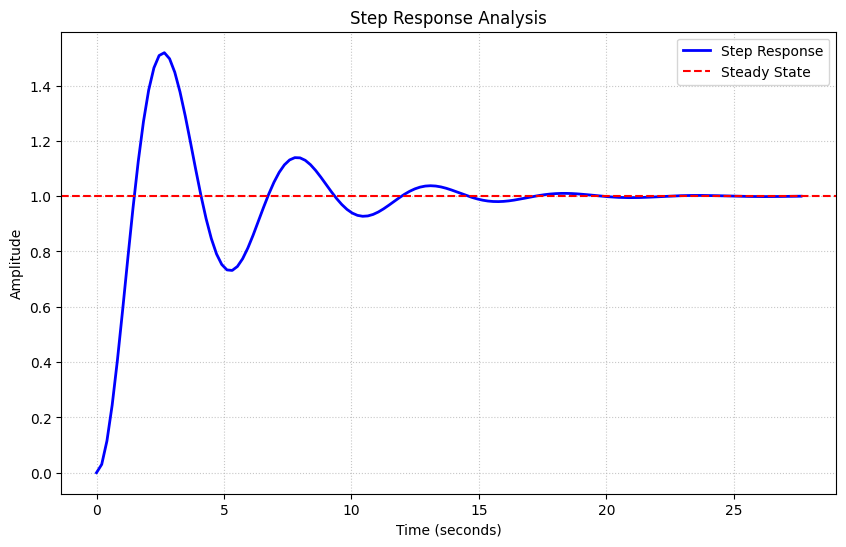

In [3]:
# User Instructions: 
# This cell computes the step response and extracts key performance metrics.

# Calculate Step Response
t, y = ct.step_response(sys)

# Extract Step Response Specifications
info = ct.step_info(sys)

print("--- Step Response Metrics ---")
print(f"Rise Time: {info['RiseTime']:.4f} s")
print(f"Settling Time: {info['SettlingTime']:.4f} s")
print(f"Overshoot: {info['Overshoot']:.4f} %")
print(f"Peak Value: {info['Peak']:.4f}")

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(t, y, label='Step Response', color='blue', linewidth=2)
plt.axhline(y=y[-1], color='r', linestyle='--', label='Steady State')
plt.title('Step Response Analysis')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.show()

--- Stability Analysis ---
Poles: [-0.25+1.19895788j -0.25-1.19895788j]
Zeros: []
Verdict: The system is ASYMPTOTICALLY STABLE.


C:\Users\Nex\AppData\Roaming\Python\Python313\site-packages\control\pzmap.py:327: FutureWarning: pole_zero_plot() return value of poles, zeros is deprecated; use pole_zero_map()
  warnings.warn(


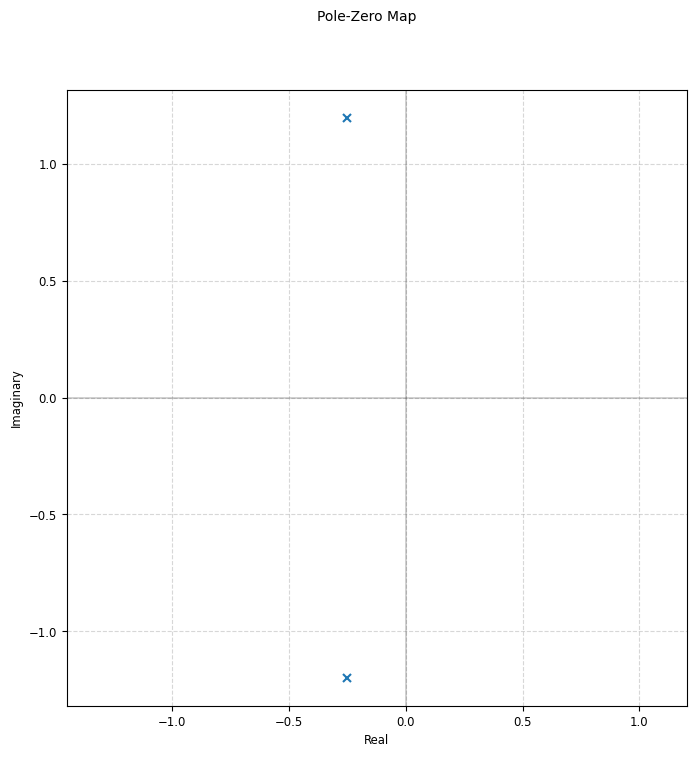

In [4]:
# User Instructions: 
# This cell plots the poles and zeros of the system and evaluates stability.

# Poles and Zeros calculation
poles = ct.poles(sys)
zeros = ct.zeros(sys)

# Stability Analysis
is_stable = np.all(np.real(poles) < 0)

print("--- Stability Analysis ---")
print(f"Poles: {poles}")
print(f"Zeros: {zeros}")

if is_stable:
    print("Verdict: The system is ASYMPTOTICALLY STABLE.")
else:
    print("Verdict: The system is UNSTABLE.")

# Pole-Zero Map Plotting
plt.figure(figsize=(8, 8))
ct.pzmap(sys, plot=True, title='Pole-Zero Map')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()